In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from torch.utils.data import DataLoader

from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

import json
import matplotlib.pyplot as plt

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-4

IMG_SIZE = 256
DATA_DIR = "Dataset_Imagenes_Robustas"

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
train_dataset = datasets.ImageFolder(
    f"{DATA_DIR}/Training",
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    f"{DATA_DIR}/Validation",
    transform=val_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

NUM_CLASSES = len(train_dataset.classes)
print(train_dataset.classes)

['Fringillidae_Serinus_serinus', 'Paridae_Hypocnemis_peruviana', 'Paridae_Saxicola_rubetra', 'Paridae_Saxicola_rubicola', 'Sin_Pajaro', 'Troglodytidae_Troglodytes_aedon', 'Troglodytidae_Troglodytes_hiemalis', 'Troglodytidae_Troglodytes_pacificus', 'Troglodytidae_Troglodytes_troglodytes', 'Turdidae_Catharus_aurantiirostris', 'Turdidae_Catharus_fuscater', 'Turdidae_Catharus_fuscescens', 'Turdidae_Catharus_guttatus', 'Turdidae_Catharus_ustulatus']


In [ ]:
# bloque para entrenar el modelo con un depth variable

# class_counts = torch.bincount(torch.tensor(train_dataset.targets))

# weights = class_counts.sum() / (len(class_counts) * class_counts.float())

# criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))

# model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)

# train_depth = 7

# for param in model.features[:-train_depth].parameters():
#     param.requires_grad = False

# model.classifier[3] = nn.Linear(
#     model.classifier[3].in_features,
#     NUM_CLASSES
# )

# optimizer = torch.optim.SGD([
#     {"params": model.classifier.parameters(), "lr": 1e-3},
#     {"params": model.features[-train_depth:].parameters(), "lr": 1e-4}], momentum=0.9, weight_decay=1e-4)

# scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size=5,
#     gamma=0.1
# )

In [6]:
train_depth = 'no fine tunning'

class_counts = torch.bincount(torch.tensor(train_dataset.targets))

weights = class_counts.sum() / (len(class_counts) * class_counts.float())

criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))

model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)

model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    NUM_CLASSES
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

In [7]:
def train_epoch(model, loader):

    model.train()
    total_loss = 0

    for imgs, labels in tqdm(loader):

        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [8]:
def evaluate(model, loader):

    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():

        for imgs, labels in loader:

            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(imgs)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1).cpu()

            all_preds.extend(preds.numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = total_loss / len(loader)

    num_classes = len(train_dataset.classes)
    
    accuracy = (np.array(all_preds) == np.array(all_labels)).mean()

    report = classification_report(
        all_labels,
        all_preds,
        labels=list(range(num_classes)),
        target_names=train_dataset.classes,
        zero_division=0
    )

    return val_loss, accuracy, report

In [9]:
model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

In [10]:
train_losses = []
val_losses = []
val_acc = []
reports = []

for epoch in range(EPOCHS):

    train_loss = train_epoch(model, train_loader)
    val_loss, val_accuracy, report = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_acc.append(val_accuracy)
    scheduler.step()
    reports.append(report)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Train loss:", train_loss)
    print("Val loss:", val_loss)

100%|██████████| 151/151 [00:32<00:00,  4.71it/s]



Epoch 1/20
Train loss: 1.8848512902954557
Val loss: 1.500784412255654


100%|██████████| 151/151 [00:32<00:00,  4.62it/s]



Epoch 2/20
Train loss: 0.5771797466159656
Val loss: 0.6762654740076799


100%|██████████| 151/151 [00:33<00:00,  4.57it/s]


...


Epoch 18/20
Train loss: 0.06218899217193687
Val loss: 0.3035497816566091


100%|██████████| 151/151 [00:33<00:00,  4.48it/s]



Epoch 19/20
Train loss: 0.06125070619094648
Val loss: 0.3035788451142323


100%|██████████| 151/151 [00:32<00:00,  4.72it/s]



Epoch 20/20
Train loss: 0.06453653428678875
Val loss: 0.30430969901812766


In [11]:
_, _, _report = evaluate(model, val_loader)
print(_report)

                                       precision    recall  f1-score   support

         Fringillidae_Serinus_serinus       0.97      0.93      0.95       155
         Paridae_Hypocnemis_peruviana       1.00      0.74      0.85        34
             Paridae_Saxicola_rubetra       0.95      0.90      0.92       409
            Paridae_Saxicola_rubicola       0.83      0.94      0.89       213
                           Sin_Pajaro       0.31      0.58      0.41        19
      Troglodytidae_Troglodytes_aedon       0.88      0.87      0.88       252
   Troglodytidae_Troglodytes_hiemalis       0.95      1.00      0.97        70
  Troglodytidae_Troglodytes_pacificus       0.96      0.89      0.92        90
Troglodytidae_Troglodytes_troglodytes       0.92      0.92      0.92       261
    Turdidae_Catharus_aurantiirostris       0.82      0.88      0.85       154
           Turdidae_Catharus_fuscater       0.99      0.92      0.96       171
         Turdidae_Catharus_fuscescens       0.87   

In [12]:
checkpoint = {
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses
}

torch.save(checkpoint, f"mobilenetv3_checkpoint_depth_{train_depth}.pth")

In [13]:
training_logs = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_acc": val_acc,
    "reports": reports
}

with open(f"training_logs_depth_{train_depth}.json", "w") as f:
    json.dump(training_logs, f, indent=2)

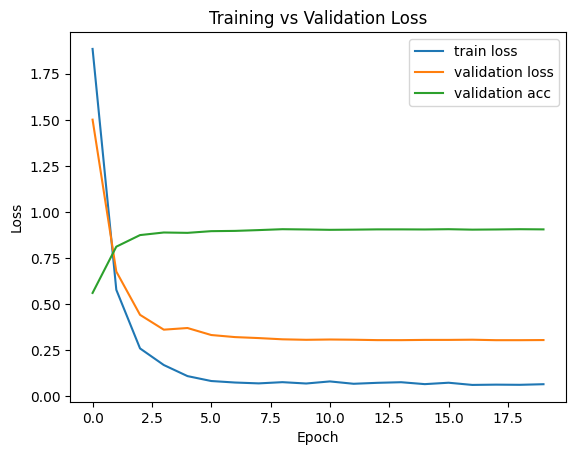

In [14]:

plt.figure()

plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="validation loss")
plt.plot(val_acc, label="validation acc")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()